# Training Evaluator

Loads a trained kinematic-reconstruction result and evaluates it on the synthetic dataset.

**What it shows**
- 50 image pairs (ground-truth flux | predicted flux) for the test split.
- A polar sky plot of all sun positions (train + val + test) where dot size = centroid error and dot colour = split.

In [1]:
import json, sys, pathlib, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import h5py
from PIL import Image
warnings.filterwarnings("ignore")

_nb   = pathlib.Path(globals().get("__vsc_ipynb_file__", pathlib.Path().resolve() / "x")).parent  # notebook dir
_src  = _nb.parent                 # .../src
_base = _src.parent                # .../master-thesis
sys.path.insert(0, str(_src))

from artist.scenario.scenario import Scenario
from artist.util import get_device, set_logger_config
from utils.synth_data import _forward_pass

set_logger_config()
import logging; logging.getLogger().setLevel(logging.WARNING)
print("Imports OK")

Imports OK


In [2]:
# ============================================================
#  CONFIG — edit this cell, then re-run all cells below
# ============================================================

# Select one heliostat (ordered by increasing distance from the target)
HELIOSTAT_ID = "AC36"   # options: AC36  AG33  AO34  AW36  BE35

# Which training-size result to load
TRAIN_SIZE = 10         # options: 1  5  10  20  25  50  75  100

N_RAYS                   = 100   # rays per light source (higher = cleaner, slower)
SURFACE_POINTS_PER_FACET = 5     # per facet (5x5 = 25 pts)

In [ ]:
%%time
# ── Load scenario + apply trained kinematic parameters ───────────────────

SCENARIO_PATH = _base / "scenarios" / "full_field_200_samples_scenario" / "scenario.h5"
KIN_PATH = (
    _base / "outputs" / "one_hel_train_sizes"
    / HELIOSTAT_ID / f"train_size_{TRAIN_SIZE}" / "kinematic_parameters.json"
)
SYNTH_DIR = _base / "scenarios" / "full_63_heli_kin_reconstruct" / "synthetic_data"

if not KIN_PATH.exists():
    raise FileNotFoundError(f"Kinematic parameters not found:\n  {KIN_PATH}")

device = get_device()
print(f"Device: {device}")

with h5py.File(SCENARIO_PATH, "r") as f:
    scenario = Scenario.load_scenario_from_hdf5(
        scenario_file=f,
        device=device,
        number_of_surface_points_per_facet=torch.tensor(
            [SURFACE_POINTS_PER_FACET, SURFACE_POINTS_PER_FACET]
        ),
    )

heliostat_group = scenario.heliostat_field.heliostat_groups[0]
heliostat_names = list(heliostat_group.names)
heliostat_idx   = heliostat_names.index(HELIOSTAT_ID)
kinematic       = heliostat_group.kinematics

# Apply trained parameters (absolute values, not deltas).
# The JSON typically contains only the single trained heliostat, not all 63.
with open(KIN_PATH) as f:
    kin_data = json.load(f)["group_0"]

json_names = kin_data["heliostat_names"]
if not set(json_names).issubset(set(heliostat_names)):
    raise ValueError(f"JSON heliostats {json_names} are not a subset of scenario heliostats")

def _t(v): return torch.tensor(v, dtype=torch.float32, device=device)

# Map JSON positions → scenario positions and apply each heliostat's parameters.
json_to_scenario = [heliostat_names.index(name) for name in json_names]
for j, s in enumerate(json_to_scenario):
    kinematic.translation_deviation_parameters.data[s] = _t(kin_data["translation_deviation_parameters"][j])
    kinematic.rotation_deviation_parameters.data[s]    = _t(kin_data["rotation_deviation_parameters"][j])
    kinematic.actuators.optimizable_parameters.data[s]     = _t(kin_data["actuator_optimizable_parameters"][j])
    kinematic.actuators.non_optimizable_parameters.data[s] = _t(kin_data["actuator_nonoptimizable_parameters"][j])

# Full [N_heli, 3] base-position tensor; zeros for heliostats not in the JSON.
trained_base_pos = torch.zeros(len(heliostat_names), 3, device=device)
for j, s in enumerate(json_to_scenario):
    trained_base_pos[s] = _t(kin_data["base_position_deviation_parameters"][j])

print(f"Scenario : {len(heliostat_names)} heliostats")
print(f"Selected : {HELIOSTAT_ID}  (index {heliostat_idx})")
print(f"JSON     : {json_names}")
print(f"Kin file : {KIN_PATH.relative_to(_base)}")

In [4]:
# ── Helpers ───────────────────────────────────────────────────────────────

def load_split(synth_dir, heli_id, split):
    """Load incident rays, GT centroids, target indices, and GT flux for one split."""
    hel_dir = synth_dir / split / heli_id
    sample_dirs = sorted(hel_dir.iterdir())
    cals, flux_list = [], []
    for d in sample_dirs:
        with open(d / "calibration_properties.json") as f:
            cals.append(json.load(f))
        img = np.array(Image.open(d / "flux_image.png").convert("L"), dtype=np.float32) / 255.0
        flux_list.append(img)
    rays         = torch.tensor([c["incident_ray_direction"] for c in cals], dtype=torch.float32)
    gt_centroids = torch.tensor([c["focal_spot_enu"]          for c in cals], dtype=torch.float32)
    target_mask  = torch.tensor([c["target_area_index"]       for c in cals], dtype=torch.long)
    gt_flux      = torch.stack([torch.from_numpy(f) for f in flux_list])
    return rays, gt_centroids, target_mask, gt_flux


def run_forward(scenario, hg, rays, heli_idx, target_mask, base_pos, device):
    """Ray-trace a single heliostat for all given rays."""
    n = rays.shape[0]
    active_mask = torch.zeros(len(hg.names), dtype=torch.long, device=device)
    active_mask[heli_idx] = n
    with torch.no_grad():
        return _forward_pass(
            scenario, hg,
            rays.to(device), active_mask, target_mask.to(device),
            base_pos, device,
        )


def centroid_error_m(pred, gt, device):
    return torch.norm(pred[:, :3].to(device) - gt[:, :3].to(device), dim=1)


def to_uint8(flux):
    f = flux.cpu().float()
    fmax = f.max()
    if fmax > 1e-12:
        f = f / fmax
    return (f * 255).clamp(0, 255).to(torch.uint8).numpy()


def rays_to_az_el(rays):
    """ARTIST incident rays [E,N,U,0] -> south-oriented azimuth and elevation (degrees)."""
    el_deg = torch.asin(-rays[:, 2].clamp(-1, 1)).rad2deg()
    az_deg = torch.atan2(rays[:, 0], rays[:, 1]).rad2deg()
    return az_deg, el_deg


print("Helpers defined")

Helpers defined


In [8]:
%%time
# ── Load test split + predict ─────────────────────────────────────────────

scenario.set_number_of_rays(N_RAYS)

test_rays, test_gt_centroids, test_target_mask, test_gt_flux = load_split(SYNTH_DIR, HELIOSTAT_ID, "test")
print(f"Test samples: {len(test_rays)}")

test_pred_centroids, test_pred_flux = run_forward(
    scenario, heliostat_group, test_rays, heliostat_idx, test_target_mask, trained_base_pos, device
)
test_errors = centroid_error_m(test_pred_centroids, test_gt_centroids, device).cpu()

print(f"Test centroid error — mean: {test_errors.mean():.4f} m  "
      f"median: {test_errors.median():.4f} m  "
      f"max: {test_errors.max():.4f} m")

Test samples: 49


NameError: name 'trained_base_pos' is not defined

NameError: name 'test_errors' is not defined

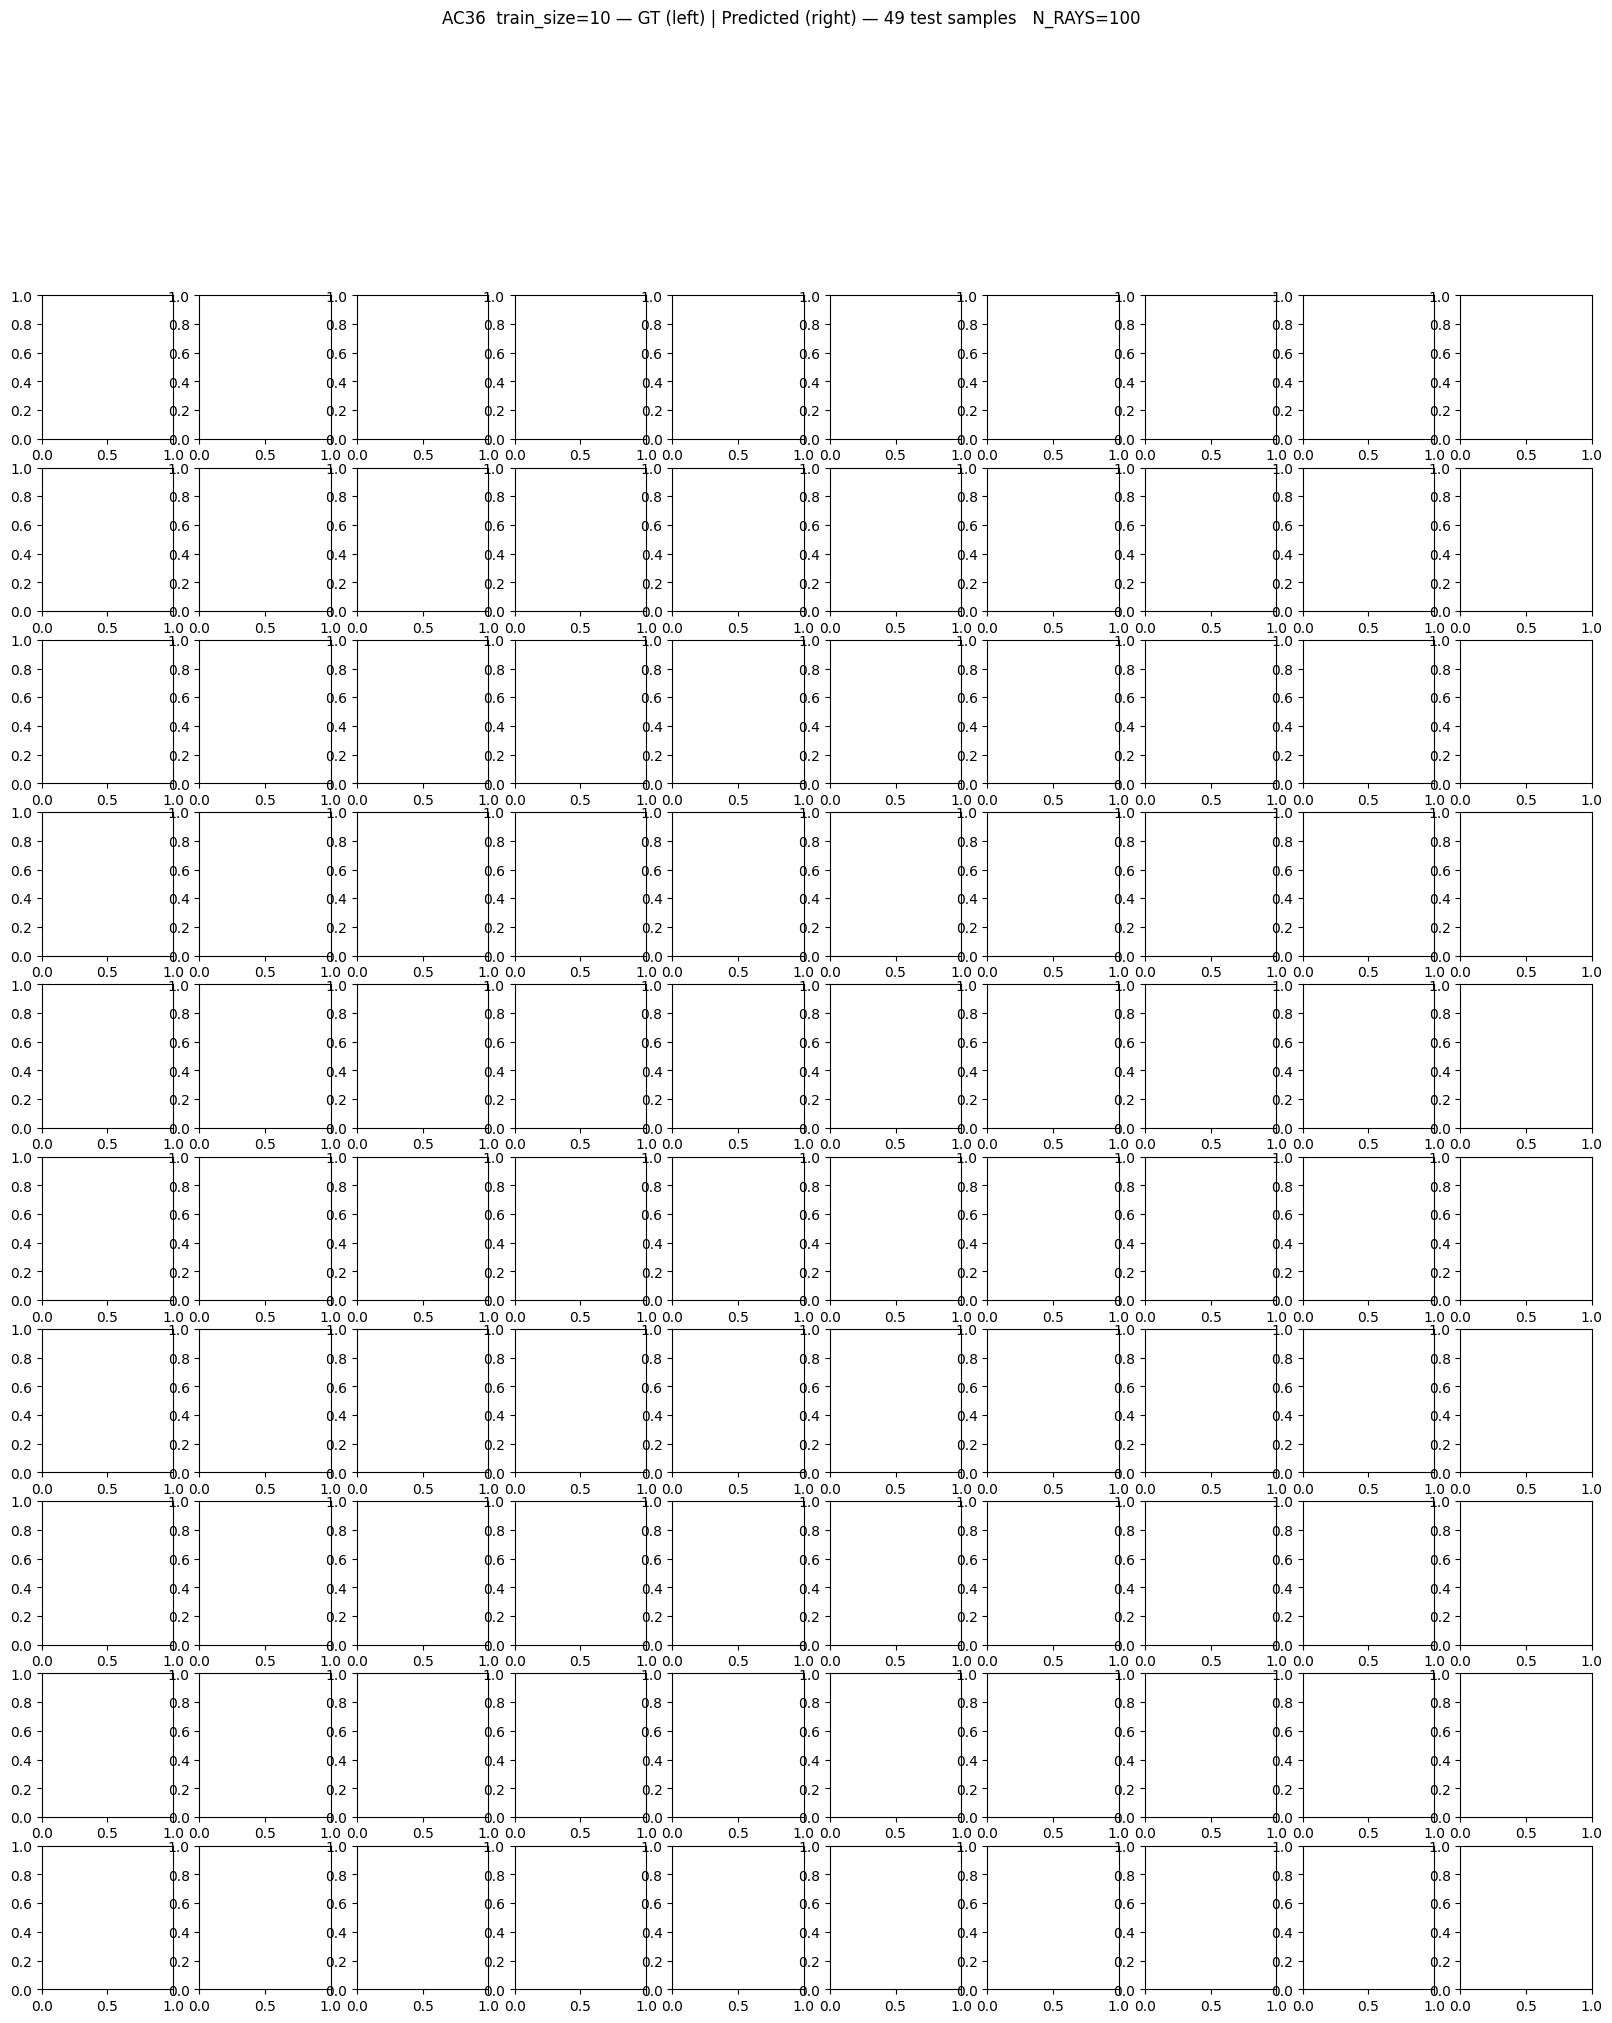

In [6]:
# ── 50 image pairs: GT (left) | Predicted (right) ────────────────────────
# Each image normalised independently to its own max (grayscale, no blur).

N             = test_gt_flux.shape[0]
PAIRS_PER_ROW = 5
ROWS          = (N + PAIRS_PER_ROW - 1) // PAIRS_PER_ROW

fig, axes = plt.subplots(
    ROWS, PAIRS_PER_ROW * 2,
    figsize=(PAIRS_PER_ROW * 4, ROWS * 2.2),
)
fig.suptitle(
    f"{HELIOSTAT_ID}  train_size={TRAIN_SIZE} — GT (left) | Predicted (right) — "
    f"{N} test samples   N_RAYS={N_RAYS}",
    fontsize=12, y=1.01,
)

med_err = test_errors.median().item()
for i in range(N):
    row      = i // PAIRS_PER_ROW
    col_pair = i % PAIRS_PER_ROW
    ax_gt = axes[row, col_pair * 2]
    ax_pr = axes[row, col_pair * 2 + 1]

    ax_gt.imshow(to_uint8(test_gt_flux[i]),   cmap="gray", vmin=0, vmax=255)
    ax_pr.imshow(to_uint8(test_pred_flux[i]), cmap="gray", vmin=0, vmax=255)

    ax_gt.set_title(f"#{i+1} GT", fontsize=7)
    err_col = "tomato" if test_errors[i].item() > med_err else "forestgreen"
    ax_pr.set_title(f"\u0394={test_errors[i]:.3f} m", fontsize=7, color=err_col)
    ax_gt.axis("off")
    ax_pr.axis("off")

for j in range(N * 2, ROWS * PAIRS_PER_ROW * 2):
    axes.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
%%time
# ── Load train + val splits + predict ────────────────────────────────────

train_rays, train_gt_c, train_tm, _ = load_split(SYNTH_DIR, HELIOSTAT_ID, "train")
val_rays,   val_gt_c,   val_tm,   _ = load_split(SYNTH_DIR, HELIOSTAT_ID, "val")
print(f"Train: {len(train_rays)}  Val: {len(val_rays)}  Test: {len(test_rays)}")

train_pred_c, _ = run_forward(scenario, heliostat_group, train_rays, heliostat_idx, train_tm, trained_base_pos, device)
val_pred_c,   _ = run_forward(scenario, heliostat_group, val_rays,   heliostat_idx, val_tm,   trained_base_pos, device)

train_errors = centroid_error_m(train_pred_c, train_gt_c, device).cpu()
val_errors   = centroid_error_m(val_pred_c,   val_gt_c,   device).cpu()

print(f"Train error — mean: {train_errors.mean():.4f} m  median: {train_errors.median():.4f} m")
print(f"Val   error — mean: {val_errors.mean():.4f} m  median: {val_errors.median():.4f} m")
print(f"Test  error — mean: {test_errors.mean():.4f} m  median: {test_errors.median():.4f} m")

In [ ]:
# ── Polar sky plot: sun position, dot size = error, colour = split ────────
#
# Polar: angle = south-oriented azimuth (0=south, 90=west)
#        radius = 90 - elevation  (0 = zenith, 90 = horizon)

splits_data = [
    (train_rays, train_errors, "#4C72B0", "train"),
    (val_rays,   val_errors,   "#DD8452", "val"),
    (test_rays,  test_errors,  "#55A868", "test"),
]

all_errors = torch.cat([train_errors, val_errors, test_errors])
err_min, err_max = all_errors.min().item(), all_errors.max().item()
err_range = max(err_max - err_min, 1e-9)

def err_to_size(e, s_min=20, s_max=300):
    norm = ((e.numpy() - err_min) / err_range).clip(0, 1)
    return s_min + norm * (s_max - s_min)


fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(7, 7))

for rays, errors, color, label in splits_data:
    az_deg, el_deg = rays_to_az_el(rays)
    ax.scatter(
        torch.deg2rad(az_deg).numpy(),
        (90.0 - el_deg).numpy(),
        s=err_to_size(errors), c=color, alpha=0.75, edgecolors="none", label=label,
    )

ax.set_theta_zero_location("S")   # 0° (south) points down
ax.set_theta_direction(-1)         # clockwise: west = 90° to the right
ax.set_rlabel_position(135)
ax.set_rticks([15, 30, 45, 60, 75, 90])
ax.set_yticklabels(["75°", "60°", "45°", "30°", "15°", "0°"], fontsize=8)
ax.set_rlim(0, 90)
ax.set_title(
    f"{HELIOSTAT_ID}  train_size={TRAIN_SIZE}\n"
    f"dot size = centroid error  (min={err_min:.4f} m  max={err_max:.4f} m)",
    fontsize=11, pad=20,
)
legend_handles = [
    mlines.Line2D([], [], marker="o", color="w", markerfacecolor=c, markersize=8, label=lbl)
    for _, _, c, lbl in splits_data
]
ax.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()